# Predicting Vehicle Resale Prices


## Step 0: Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

## Step 1: Load the dataset


In [ ]:
df = pd.read_csv('used_car_data.csv')
df.head()

,Car_Age,Mileage_km,Condition,Fuel_Type,Transmission,Owner_Count,Original_Price_Lakh,Resale_Price_Lakh
0,7,59514.0,Excellent,Diesel,Manual,1.0,10.78,5.60
1,4,59640.0,Fair,Diesel,Manual,1.0,8.61,5.03
2,11,187682.0,Fair,CNG,Manual,1.0,13.84,2.56
3,8,NaN,Good,CNG,Manual,1.0,18.59,6.41
4,5,62440.0,Fair,CNG,Manual,1.0,6.23,2.82


## Step 2: Understand the data

In [ ]:
print("Rows and columns:", df.shape)
df.info()

Rows and columns: (150, 8)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car_Age              150 non-null    int64  
 1   Mileage_km           145 non-null    float64
 2   Condition            147 non-null    str    
 3   Fuel_Type            150 non-null    str    
 4   Transmission         150 non-null    str    
 5   Owner_Count          148 non-null    float64
 6   Original_Price_Lakh  150 non-null    float64
 7   Resale_Price_Lakh    150 non-null    float64
dtypes: float64(4), int64(1), str(3)
memory usage: 9.5 KB


In [ ]:
df.describe()

,Car_Age,Mileage_km,Owner_Count,Original_Price_Lakh,Resale_Price_Lakh
count,150.000000,145.000000,148.000000,150.00000,150.000000
mean,6.866667,89721.137931,1.601351,12.19080,5.133600
std,3.513477,53320.914238,0.687496,4.48868,2.914708
min,1.000000,9734.000000,1.000000,4.37000,1.100000
25%,4.000000,46176.000000,1.000000,8.48250,3.002500
50%,7.000000,84000.000000,1.000000,12.14500,4.690000
75%,10.000000,128032.000000,2.000000,16.37000,6.367500
max,12.000000,215832.000000,3.000000,19.82000,15.600000


## Step 3: Pre-processing
### 3.1 Check missing values

In [ ]:
df.isnull().sum()

Car_Age                0
Mileage_km             5
Condition              3
Fuel_Type              0
Transmission           0
Owner_Count            2
Original_Price_Lakh    0
Resale_Price_Lakh      0
dtype: int64

### 3.2 Check duplicate rows

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 4


In [ ]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 146


### 3.3 Fill the missing values
- Numbers (`Mileage_km`, `Owner_Count`) → fill with the **median**
- Text column (`Condition`) → fill with the **mode** (most common value)

In [ ]:
df['Mileage_km']  = df['Mileage_km'].fillna(df['Mileage_km'].median())
df['Owner_Count'] = df['Owner_Count'].fillna(df['Owner_Count'].median())
df['Condition']   = df['Condition'].fillna(df['Condition'].mode()[0])

print("Missing values left:", df.isnull().sum().sum())

Missing values left: 0


## Step 4: Feature construction
Creating **new columns** from existing ones.

1. `Mileage_Per_Year = Mileage_km / Car_Age` → tells us how heavily the car was used each year.
2. `Estimated_Value` → a common rule of thumb in the used-car market is that a car loses about **10% of its original price every year**. So `Estimated_Value = Original_Price × (1 − 0.10 × Car_Age)`. We keep a minimum of 10% of the original price so the value never becomes zero or negative.

In [ ]:
df['Mileage_Per_Year'] = df['Mileage_km'] / df['Car_Age']

df['Estimated_Value'] = df['Original_Price_Lakh'] * (1 - 0.10 * df['Car_Age'])
df['Estimated_Value'] = df['Estimated_Value'].clip(lower=0.1 * df['Original_Price_Lakh'])   # minimum 10% of original price

df[['Car_Age', 'Mileage_km', 'Mileage_Per_Year', 'Original_Price_Lakh', 'Estimated_Value']].head()

,Car_Age,Mileage_km,Mileage_Per_Year,Original_Price_Lakh,Estimated_Value
0,7,59514.0,8502.0,10.78,3.234
1,4,59640.0,14910.0,8.61,5.166
2,11,187682.0,17062.0,13.84,1.384
3,8,84000.0,10500.0,18.59,3.718
4,5,62440.0,12488.0,6.23,3.115


## Step 5: Feature engineering (convert text to numbers)
Machine learning models understand only numbers, so:
- **Condition** has an order (Poor < Fair < Good < Excellent) → **label encoding** (1, 2, 3, 4)
- **Fuel_Type** and **Transmission** have no order → **one-hot encoding** (0/1 columns)

In [ ]:
# Condition -> numbers with order
df['Condition'] = df['Condition'].map({'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4})

# Fuel_Type and Transmission -> 0/1 columns
df = pd.get_dummies(df, columns=['Fuel_Type', 'Transmission'], drop_first=True, dtype=int)
df.head()

,Car_Age,Mileage_km,Condition,Owner_Count,Original_Price_Lakh,Resale_Price_Lakh,Mileage_Per_Year,Estimated_Value,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Manual
0,7,59514.0,4,1.0,10.78,5.60,8502.0,3.234,1,0,1
1,4,59640.0,2,1.0,8.61,5.03,14910.0,5.166,1,0,1
2,11,187682.0,2,1.0,13.84,2.56,17062.0,1.384,0,0,1
3,8,84000.0,3,1.0,18.59,6.41,10500.0,3.718,0,0,1
4,5,62440.0,2,1.0,6.23,2.82,12488.0,3.115,0,0,1


In [ ]:
print(df.corr()['Resale_Price_Lakh'].sort_values(ascending=False))

Resale_Price_Lakh      1.000000
Estimated_Value        0.930077
Original_Price_Lakh    0.519556
Fuel_Type_Petrol       0.057895
Condition              0.056400
Fuel_Type_Diesel       0.004416
Mileage_Per_Year      -0.019264
Transmission_Manual   -0.047382
Owner_Count           -0.110934
Mileage_km            -0.620293
Car_Age               -0.701921
Name: Resale_Price_Lakh, dtype: float64


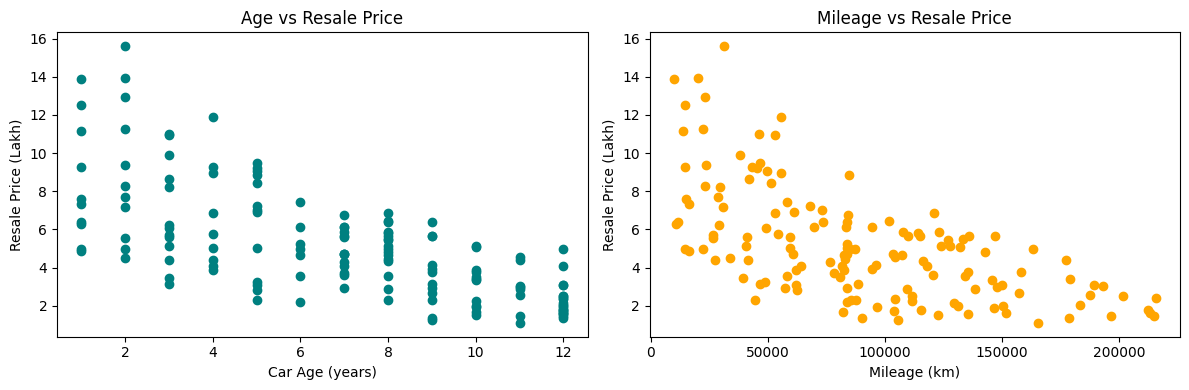

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(df['Car_Age'], df['Resale_Price_Lakh'], color='teal')
plt.xlabel('Car Age (years)')
plt.ylabel('Resale Price (Lakh)')
plt.title('Age vs Resale Price')

plt.subplot(1, 2, 2)
plt.scatter(df['Mileage_km'], df['Resale_Price_Lakh'], color='orange')
plt.xlabel('Mileage (km)')
plt.ylabel('Resale Price (Lakh)')
plt.title('Mileage vs Resale Price')

plt.tight_layout()
plt.show()

## Step 6: Train-test split


In [ ]:
X = df.drop('Resale_Price_Lakh', axis=1)
y = df['Resale_Price_Lakh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 116
Testing rows : 30


## Step 7: Standardization


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Step 8: Train 3 models and compare


### Model 1: Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

lr_r2  = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
print("R2 score :", round(lr_r2, 3))
print("MAE      :", round(lr_mae, 3), "lakh")

R2 score : 0.96
MAE      : 0.493 lakh


### Model 2: Decision Tree

In [ ]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)

dt_r2  = r2_score(y_test, dt_pred)
dt_mae = mean_absolute_error(y_test, dt_pred)
print("R2 score :", round(dt_r2, 3))
print("MAE      :", round(dt_mae, 3), "lakh")

R2 score : 0.944
MAE      : 0.669 lakh


### Model 3: Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

rf_r2  = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
print("R2 score :", round(rf_r2, 3))
print("MAE      :", round(rf_mae, 3), "lakh")

R2 score : 0.914
MAE      : 0.69 lakh


### Comparison of all 3 models

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [round(lr_r2, 3), round(dt_r2, 3), round(rf_r2, 3)],
    'MAE (Lakh)': [round(lr_mae, 3), round(dt_mae, 3), round(rf_mae, 3)]
})
comparison

,Model,R2 Score,MAE (Lakh)
0,Linear Regression,0.960,0.493
1,Decision Tree,0.944,0.669
2,Random Forest,0.914,0.690


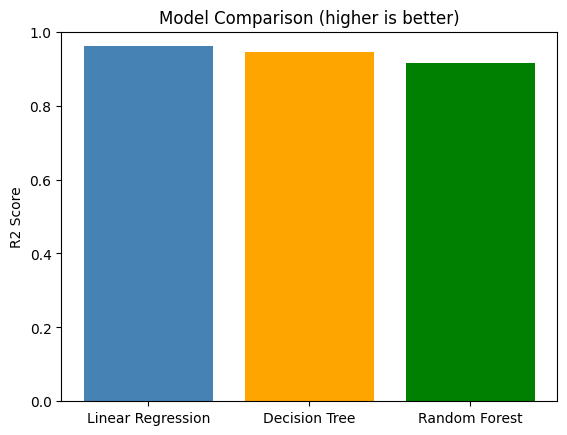

In [ ]:
plt.bar(comparison['Model'], comparison['R2 Score'], color=['steelblue', 'orange', 'green'])
plt.ylabel('R2 Score')
plt.title('Model Comparison (higher is better)')
plt.ylim(0, 1)
plt.show()

## Step 9: Final model and prediction


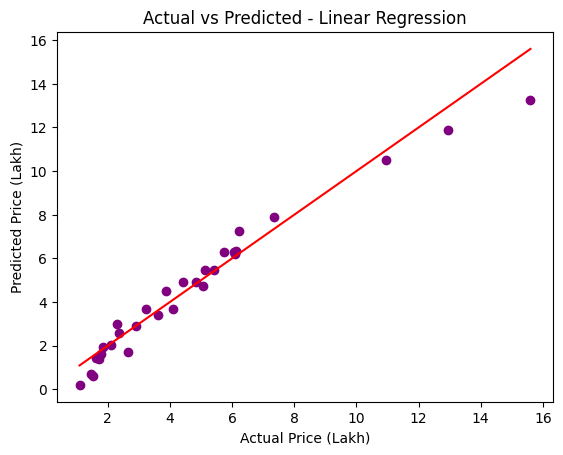

In [ ]:
plt.scatter(y_test, lr_pred, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')   # perfect-prediction line
plt.xlabel('Actual Price (Lakh)')
plt.ylabel('Predicted Price (Lakh)')
plt.title('Actual vs Predicted - Linear Regression')
plt.show()

### Predict the price of a new car
Example: a **5-year-old diesel manual car, 60,000 km driven, Good condition, 1 owner, original price ₹8 lakh**.

You can change the values and re-run the cell.

In [ ]:
new_car = pd.DataFrame([{
    'Car_Age': 5,
    'Mileage_km': 60000,
    'Condition': 3,               # 1=Poor, 2=Fair, 3=Good, 4=Excellent
    'Owner_Count': 1,
    'Original_Price_Lakh': 8,
    'Mileage_Per_Year': 60000 / 5,
    'Estimated_Value': 8 * (1 - 0.10 * 5),   # 8 lakh x (1 - 10% x 5 years)
    'Fuel_Type_Diesel': 1,        # 1 if Diesel else 0
    'Fuel_Type_Petrol': 0,        # 1 if Petrol else 0 (both 0 means CNG)
    'Transmission_Manual': 1      # 1 if Manual, 0 if Automatic
}])

new_car = new_car[X.columns]                 # same column order as training
new_car_scaled = scaler.transform(new_car)   # same scaling as training

predicted_price = lr.predict(new_car_scaled)[0]
print("Predicted resale price: Rs.", round(predicted_price, 2), "Lakh")

Predicted resale price: Rs. 4.91 Lakh


## Conclusion
- We loaded the data, removed duplicate rows and filled missing values.
- We created new features (`Mileage_Per_Year`, `Estimated_Value`) and converted text columns to numbers.
- We split the data, standardized it, and compared 3 regression models.
- **Linear Regression** gave the best result (highest R² and lowest error), so it is our final model.
- Creating a good feature (`Estimated_Value`) improved accuracy a lot – good features often matter more than a complex algorithm.

**Future scope:** use a real dataset (e.g. CarDekho from Kaggle) and add more features such as brand, model and city.